# DeepTopic motif activity analysis

Analyze motif activity across topics — the CREsted analog of ChromBPNet marginalization.
Instead of running motifs through individual cell-type models, we quantify:

1. **MoDISco seqlet counts** — how many times each motif's seqlets appear per topic (from contributions)
2. **HOMER enrichment** — known motif enrichment in topic regions
3. **Topic-to-cell-type mapping** — project motif activity to cell types via topic assignments

Adapted from `bin/3_single_task_models/4_marginalization_analysis.ipynb` (ChromBPNet).

**Inputs:**
- `crested_model/modisco/Topic*/Topic*.modisco.h5` — MoDISco results per topic
- `crested_model/motifs/cluster/cluster_key.txt` — cluster membership
- `crested_model/motifs/meme/combined.meme` — motif PWMs
- `crested_model/motifs/tfs_initial.txt` — TF annotations
- `annotated/motifs/motif_enrichment_summary.tsv` — HOMER enrichment
- `summary/topic_categories.tsv` — topic → cell type mapping

**Outputs:**
- `crested_model/motifs/analysis/seqlet_count_matrix.csv` — motif x topic seqlet counts
- `crested_model/motifs/analysis/seqlet_clustermap.pdf` — clustered heatmap
- `crested_model/motifs/analysis/homer_enrichment_clustermap.pdf` — HOMER enrichment heatmap
- `crested_model/motifs/analysis/motif_activity_celltype.pdf` — projected to cell types

# Set-up

In [1]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import logomaker as lm
from tangermeme.io import read_meme

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {'A': '#109648', 'C': '#255C99', 'G': '#F7B32B', 'T': '#D62839'}

In [2]:
# Paths
dataset = 'sc-islet-differentiation_10X-Multiome'
subset = 'all/n100'
base_dir = f'/cellar/users/aklie/data/datasets/{dataset}'
results_dir = f'{base_dir}/results/4_topic_models/{subset}'
motif_dir = f'{results_dir}/crested_model/motifs'
modisco_dir = f'{results_dir}/crested_model/modisco'

path_motif_file = f'{motif_dir}/meme/combined.meme'
path_motif_annotation = f'{motif_dir}/tfs_initial.txt'
path_cluster_key = f'{motif_dir}/cluster/cluster_key.txt'
path_homer = f'{results_dir}/annotated/motifs/motif_enrichment_summary.tsv'
path_topic_cats = f'{results_dir}/summary/topic_categories.tsv'

path_out = f'{motif_dir}/analysis'
os.makedirs(path_out, exist_ok=True)

# Load cell type colors
cell_type_meta = pd.read_csv(f'{base_dir}/config/cell_type_metadata.tsv', sep='\t')
color_dict = dict(zip(cell_type_meta['cell_type'], cell_type_meta['color']))
celltype_order = cell_type_meta['cell_type'].tolist()

# Load data

In [3]:
# Load motif annotations
motif_dict = read_meme(path_motif_file)
initial_motifs = pd.read_csv(path_motif_annotation, sep='\t', header=None, skiprows=0,
                              names=['cluster_name', 'top_tomtom_annotation', 'evalue'])
annotation_dict = initial_motifs.set_index('cluster_name')['top_tomtom_annotation'].to_dict()
names = initial_motifs['cluster_name'].tolist()
print(f'{len(names)} motifs loaded')

# Load cluster key
cluster_members = {}
with open(path_cluster_key) as f:
    for line in f:
        parts = line.strip().split('\t')
        cluster_members[parts[0]] = parts[1].split(',')

# Map: raw pattern -> cluster
pattern_to_cluster = {}
for cluster, members in cluster_members.items():
    for m in members:
        pattern_to_cluster[m] = cluster

# Load topic categories
topic_cats = pd.read_csv(path_topic_cats, sep='\t')
cat_colors = {
    'one-to-one': '#2ca02c', 'lineage': '#1f77b4', 'shared': '#ff7f0e',
    'structural': '#7f7f7f', 'batch-driven': '#d62728', 'unannotated': '#bcbd22',
}

all_topics = [f'Topic{i}' for i in range(1, 101)]

50 motifs loaded


# Build seqlet count matrix from MoDISco

For each topic, open its MoDISco h5 and count seqlets per pattern.
Map raw patterns to clustered motifs using `cluster_key.txt`.

In [4]:
seqlet_counts = pd.DataFrame(0, index=names, columns=all_topics, dtype=int)

for topic in all_topics:
    h5_path = f'{modisco_dir}/{topic}/{topic}.modisco.h5'
    if not os.path.exists(h5_path):
        print(f'  Missing: {topic}')
        continue

    with h5py.File(h5_path, 'r') as f:
        for group_name in ['pos_patterns', 'neg_patterns']:
            if group_name not in f:
                continue
            for pattern_name in f[group_name]:
                # Raw pattern name like Topic1.pattern_3.pfm
                raw_name = f'{topic}.{pattern_name}.pfm'
                n_seqlets = int(f[f'{group_name}/{pattern_name}/seqlets/n_seqlets'][0])

                cluster = pattern_to_cluster.get(raw_name)
                if cluster and cluster in seqlet_counts.index:
                    seqlet_counts.loc[cluster, topic] += n_seqlets

print(f'Seqlet count matrix: {seqlet_counts.shape}')
print(f'Total seqlets: {seqlet_counts.sum().sum():,}')
print(f'Non-zero entries: {(seqlet_counts > 0).sum().sum()} / {seqlet_counts.size}')

Seqlet count matrix: (50, 100)
Total seqlets: 87,463
Non-zero entries: 281 / 5000


In [5]:
# Save raw counts
seqlet_counts.to_csv(f'{path_out}/seqlet_count_matrix.csv')

# Z-score across topics for visualization
seqlet_z = seqlet_counts.apply(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else pd.Series(0.0, index=x.index), axis=1)
seqlet_z = seqlet_z.fillna(0)
seqlet_z.to_csv(f'{path_out}/seqlet_count_zscore.csv')

# Seqlet count clustermap (analog of marginalization clustermap)

Active motifs (>= 3 topics): 28 / 50


Saved seqlet count clustermap


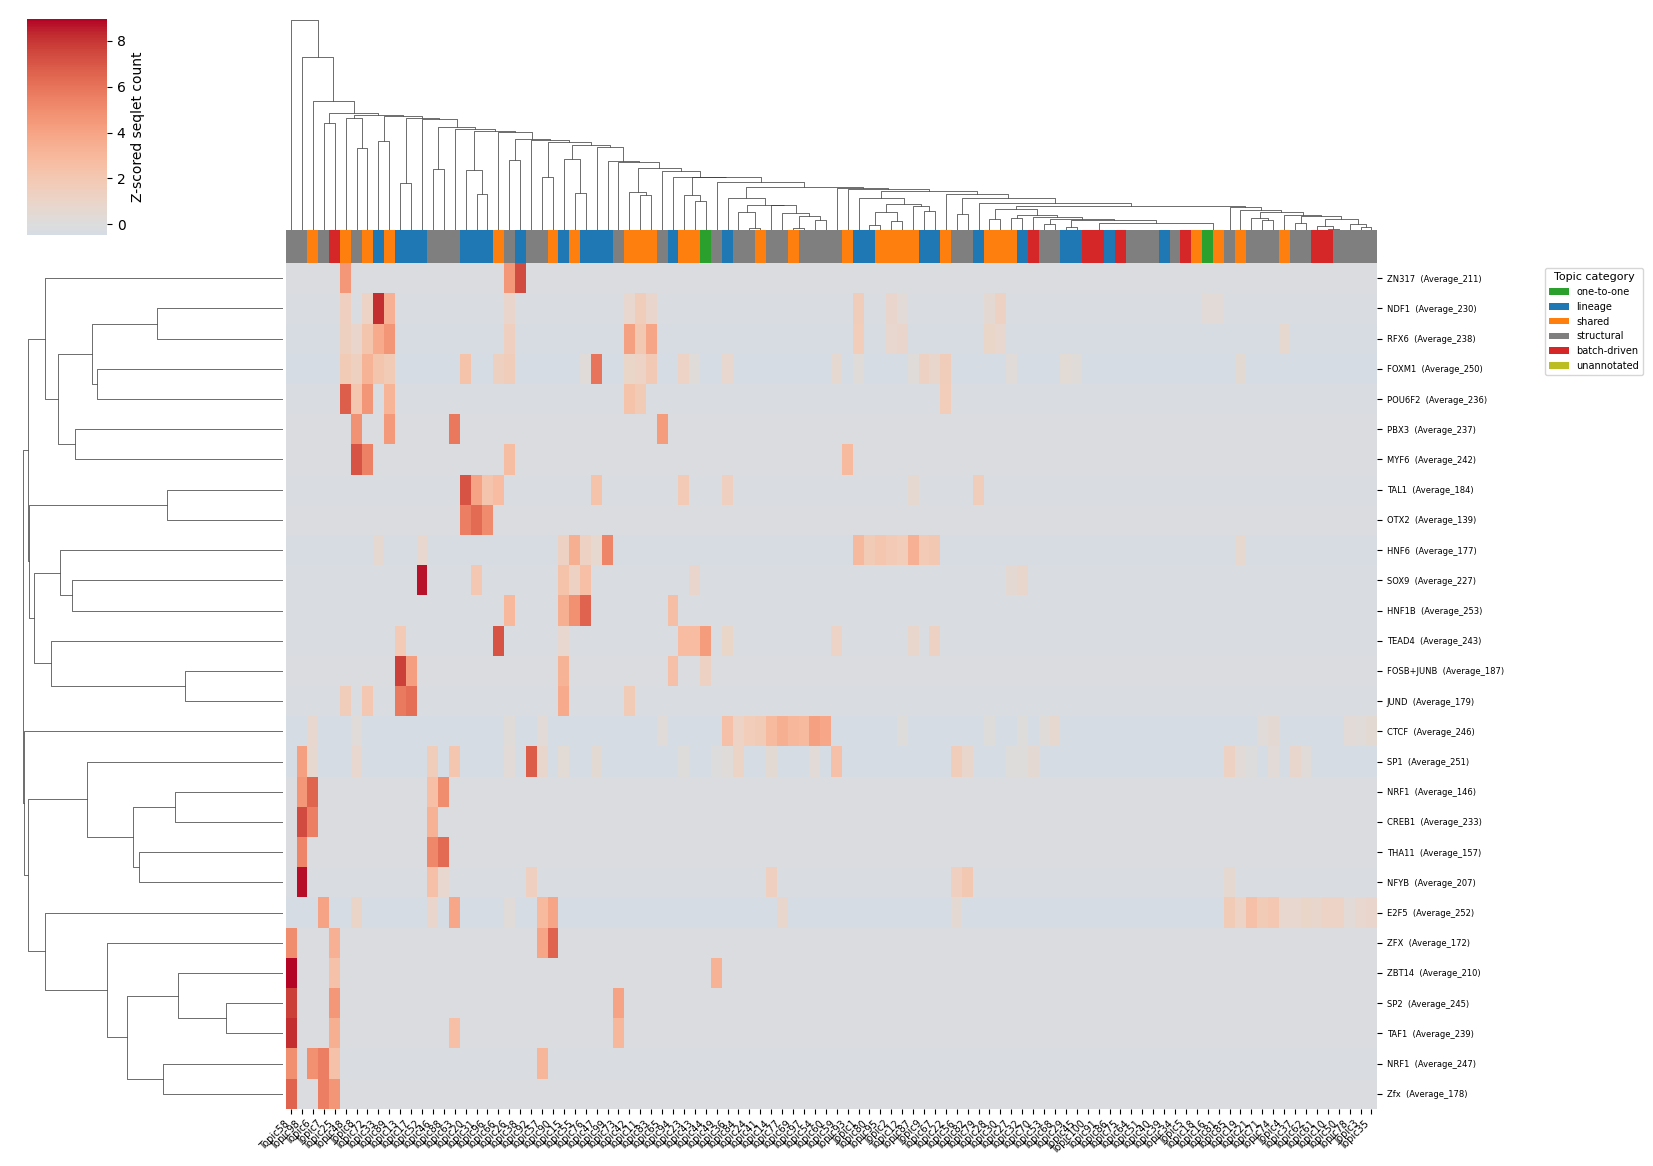

In [6]:
# Filter to motifs with at least some signal (non-zero in at least 3 topics)
active_motifs = seqlet_counts.index[seqlet_counts.gt(0).sum(axis=1) >= 3]
print(f'Active motifs (>= 3 topics): {len(active_motifs)} / {len(names)}')

# Motif labels
motif_labels = {m: annotation_dict.get(m, m).split('_')[0] for m in names}

# Topic column colors
topic_cat_dict = dict(zip(topic_cats['topic'], topic_cats['category']))
col_colors = [cat_colors.get(topic_cat_dict.get(t, ''), '#999999') for t in all_topics]

# Plot
plot_data = seqlet_z.loc[active_motifs]
plot_data.index = [f'{motif_labels[m]}  ({m})' for m in active_motifs]

g = sns.clustermap(
    plot_data,
    cmap='coolwarm',
    center=0,
    figsize=(16, max(12, len(active_motifs) * 0.35)),
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    cbar_kws={'label': 'Z-scored seqlet count'},
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1.0),
                     title='Topic category', fontsize=7, title_fontsize=8)

plt.savefig(f'{path_out}/seqlet_clustermap.pdf', dpi=300, bbox_inches='tight')
print('Saved seqlet count clustermap')
plt.show()

# HOMER enrichment heatmap

Use the pre-computed HOMER known motif enrichment results (log p-values).

In [7]:
# Load HOMER enrichment summary
homer = pd.read_csv(path_homer, sep='\t')
print(f'HOMER enrichment: {len(homer)} rows, {homer["topic"].nunique()} topics')

# Get top motifs per topic (rank <= 5) and find the most recurrent TFs
top_homer = homer[homer['rank'] <= 10]
top_tfs = top_homer['motif_name'].value_counts().head(30).index.tolist()
print(f'Top 30 recurrent TFs from HOMER: {top_tfs[:10]}...')

# Build enrichment matrix for top TFs
homer_matrix = pd.DataFrame(0.0, index=top_tfs, columns=all_topics)
for _, row in homer.iterrows():
    if row['motif_name'] in top_tfs and row['topic'] in all_topics:
        homer_matrix.loc[row['motif_name'], row['topic']] = -row['log_p_value']  # positive = more enriched

print(f'HOMER enrichment matrix: {homer_matrix.shape}')

HOMER enrichment: 1980 rows, 99 topics
Top 30 recurrent TFs from HOMER: ['CTCF', 'BORIS', 'NFY', 'FOXA1', 'SeqBias: CG bias', 'SeqBias: polyA-repeat', 'Sp1', 'Sp5', 'Ronin', 'TEAD1']...
HOMER enrichment matrix: (30, 100)


Saved HOMER enrichment clustermap


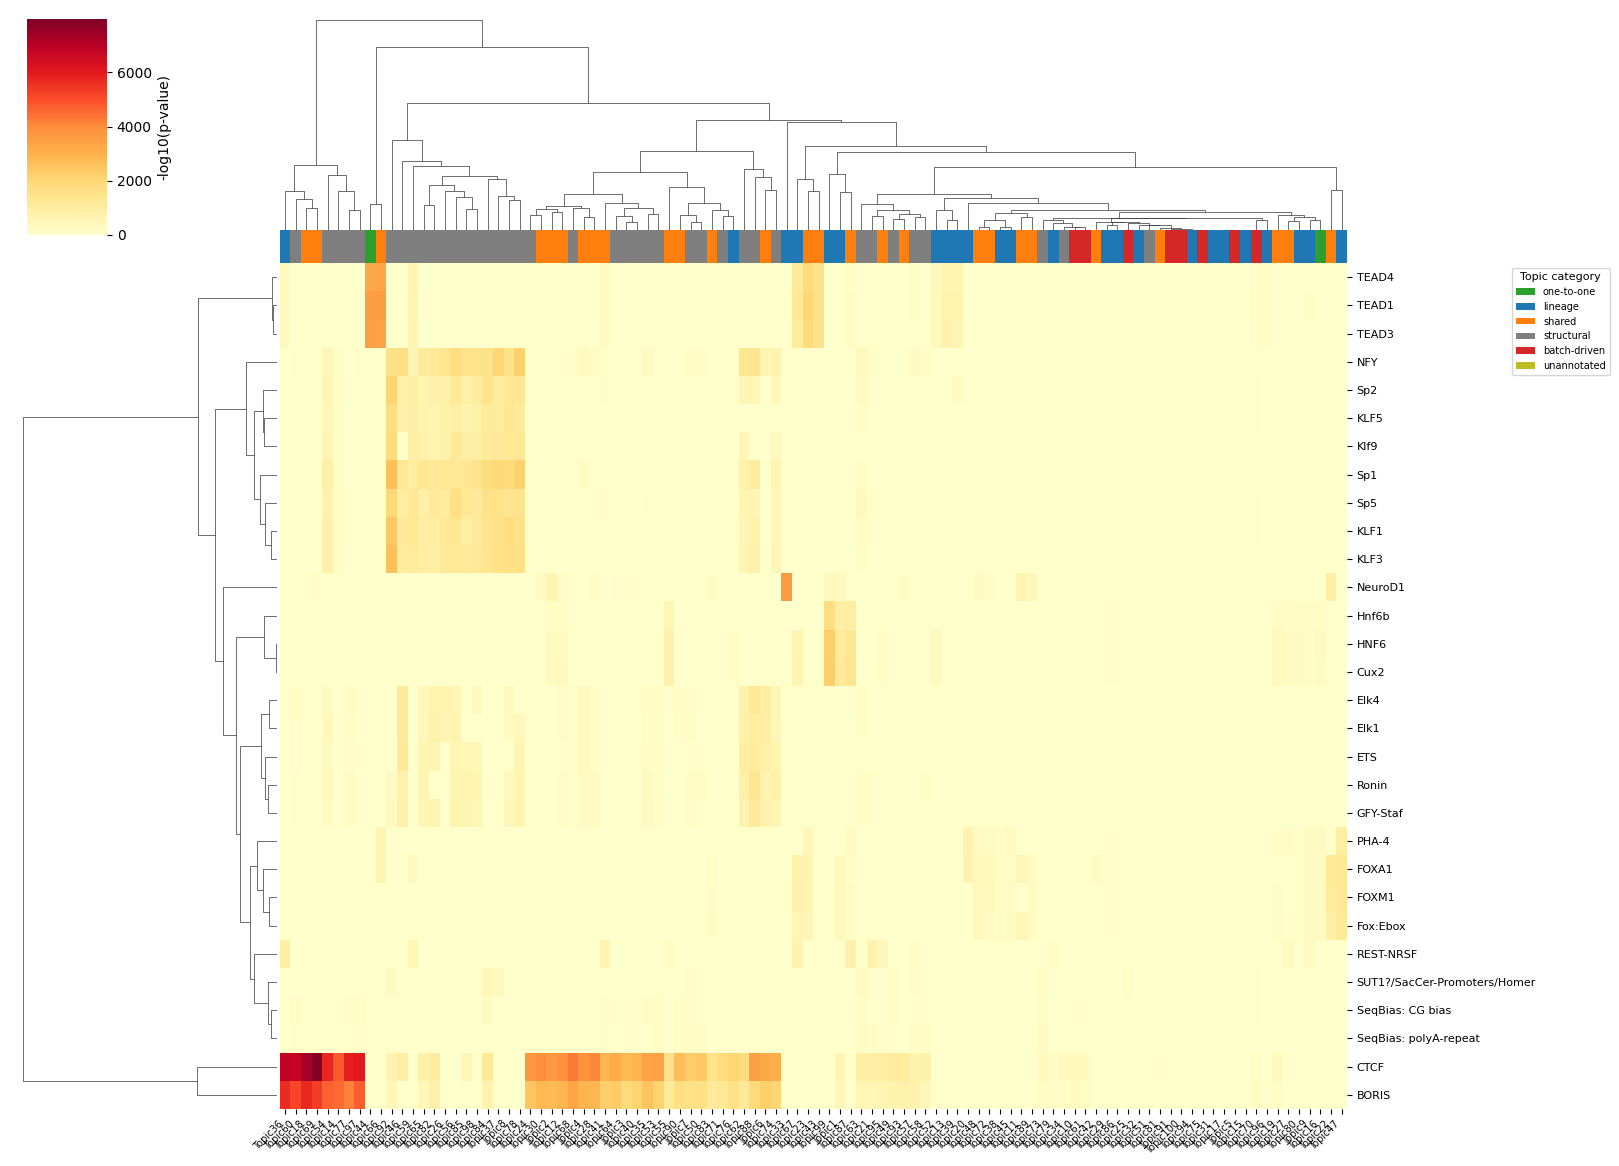

In [8]:
# Plot HOMER enrichment clustermap
g = sns.clustermap(
    homer_matrix,
    cmap='YlOrRd',
    figsize=(16, 12),
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    cbar_kws={'label': '-log10(p-value)'},
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1.0),
                     title='Topic category', fontsize=7, title_fontsize=8)

plt.savefig(f'{path_out}/homer_enrichment_clustermap.pdf', dpi=300, bbox_inches='tight')
print('Saved HOMER enrichment clustermap')
plt.show()

# Project motif activity to cell types

Map topic-level motif activity to cell types using the topic → cell type assignments.
For each cell type, sum seqlet counts across its assigned topics.

In [9]:
# Build topic → cell type weight matrix from topic_categories
# Use one-to-one and lineage topics (most confident assignments)
ct_topics = {}  # cell_type -> list of topics
for _, row in topic_cats.iterrows():
    if row['category'] in ['one-to-one', 'lineage', 'shared']:
        cell_types = [ct.strip() for ct in row['cell_types_list'].split(',')]
        for ct in cell_types:
            if ct not in ct_topics:
                ct_topics[ct] = []
            ct_topics[ct].append(row['topic'])

print(f'Cell types with topic assignments: {len(ct_topics)}')
for ct in sorted(ct_topics.keys()):
    print(f'  {ct}: {len(ct_topics[ct])} topics')

Cell types with topic assignments: 22
  DE: 6 topics
  ENP_phase1: 11 topics
  FB_FLT1: 6 topics
  PFG1: 10 topics
  PFG2: 19 topics
  PGT1: 9 topics
  PGT2: 9 topics
  PGT3: 15 topics
  PP1: 11 topics
  PP2: 11 topics
  SC_delta_GHRL: 14 topics
  early_ENP: 12 topics
  early_SC_EC: 13 topics
  early_SC_alpha: 11 topics
  early_SC_beta: 12 topics
  exocrine: 15 topics
  late_ENP: 9 topics
  late_SC_EC: 14 topics
  late_SC_alpha: 10 topics
  late_SC_beta: 11 topics
  liver: 11 topics
  proliferating_endocrine: 11 topics


In [10]:
# Aggregate seqlet counts to cell type level
ct_order = [ct for ct in celltype_order if ct in ct_topics]
ct_seqlets = pd.DataFrame(0, index=active_motifs, columns=ct_order, dtype=float)

for ct in ct_order:
    topics_for_ct = [t for t in ct_topics[ct] if t in seqlet_counts.columns]
    if topics_for_ct:
        ct_seqlets[ct] = seqlet_counts.loc[active_motifs, topics_for_ct].sum(axis=1)

# Z-score across cell types
ct_seqlets_z = ct_seqlets.apply(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else pd.Series(0.0, index=x.index), axis=1)
ct_seqlets_z = ct_seqlets_z.fillna(0)

print(f'Cell type motif matrix: {ct_seqlets_z.shape}')

Cell type motif matrix: (28, 22)


Saved cell-type-level motif activity clustermap


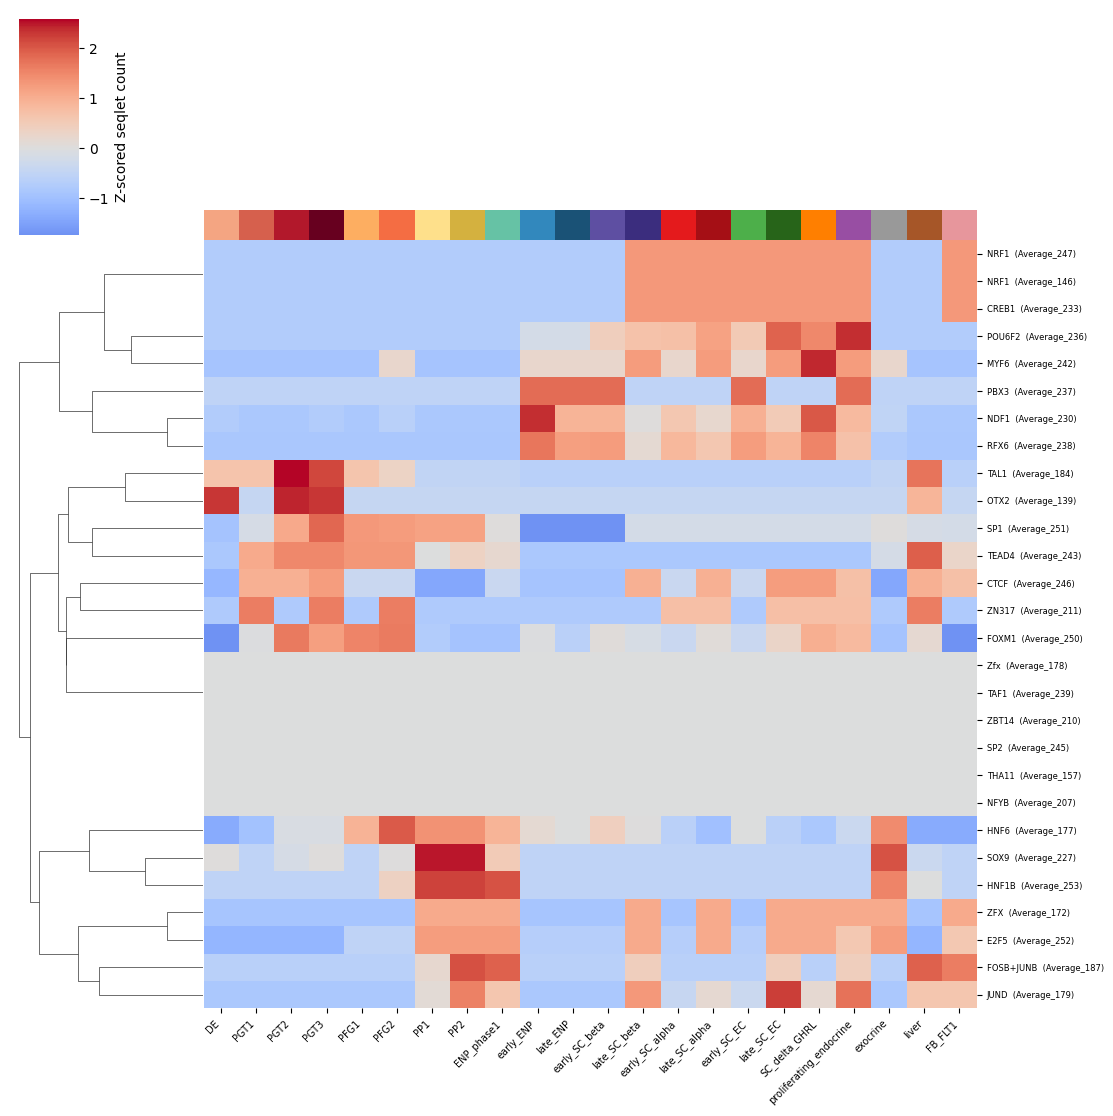

In [11]:
# Plot cell-type-level motif clustermap (analog of ChromBPNet marginalization clustermap)
ct_col_colors = [color_dict.get(ct, '#999999') for ct in ct_order]

plot_ct = ct_seqlets_z.copy()
plot_ct.index = [f'{motif_labels[m]}  ({m})' for m in active_motifs]

g = sns.clustermap(
    plot_ct,
    cmap='coolwarm',
    center=0,
    figsize=(12, max(12, len(active_motifs) * 0.35)),
    row_cluster=True,
    col_cluster=False,
    col_colors=ct_col_colors,
    cbar_kws={'label': 'Z-scored seqlet count'},
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)

plt.savefig(f'{path_out}/motif_activity_celltype.pdf', dpi=300, bbox_inches='tight')
print('Saved cell-type-level motif activity clustermap')
plt.show()

# Save results

In [12]:
ct_seqlets.to_csv(f'{path_out}/motif_activity_celltype.csv')
ct_seqlets_z.to_csv(f'{path_out}/motif_activity_celltype_zscore.csv')
homer_matrix.to_csv(f'{path_out}/homer_enrichment_matrix.csv')
print(f'Saved all results to {path_out}/')

Saved all results to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_topic_models/all/n100/crested_model/motifs/analysis/


# TF expression overlay

For ambiguous TF families, overlay motif activity with pseudobulk expression
to resolve which family member is active (same approach as ChromBPNet notebook 4).

In [13]:
# Load pseudobulk TF expression
pseudobulk_path = f'{base_dir}/results/2_process_data/pseudobulk_tf_expression.csv'
if os.path.exists(pseudobulk_path):
    pseudobulk = pd.read_csv(pseudobulk_path, index_col=0)
    ct_in_expr = [ct for ct in ct_order if ct in pseudobulk.index]
    pseudobulk = pseudobulk.reindex(ct_in_expr)
    print(f'Pseudobulk expression: {pseudobulk.shape}')

    # TF families from ChromBPNet curation
    tf_families = {
        'FOX': ['FOXA1', 'FOXA2', 'FOXB1', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1', 'FOXO1', 'FOXP1'],
        'HNF4': ['HNF4A', 'HNF4G'],
        'HNF1': ['HNF1A', 'HNF1B'],
        'HNF6': ['ONECUT1', 'ONECUT2'],
        'RFX': ['RFX1', 'RFX2', 'RFX4', 'RFX5', 'RFX6'],
        'GATA': ['GATA4', 'GATA6'],
        'PAX': ['PAX4', 'PAX6'],
        'NKX': ['NKX2-2', 'NKX6-1'],
        'ETS': ['ETV5', 'ETV6', 'ELK1', 'ETS1'],
        'MAF': ['MAFA', 'MAFB', 'MAFK'],
        'TEAD': ['TEAD1', 'TEAD4'],
        'SOX': ['SOX2', 'SOX9', 'SOX17'],
        'SP': ['SP1', 'SP2'],
        'CEBP': ['CEBPA', 'CEBPB', 'CEBPD'],
    }

    from scipy.stats import pearsonr

    resolution_results = []
    for motif in active_motifs:
        ann = annotation_dict.get(motif, '').split('_')[0].split('.')[0].upper()
        if motif not in ct_seqlets.index:
            continue
        marg = ct_seqlets.loc[motif, ct_in_expr].values

        for family, members in tf_families.items():
            if family.upper() in ann or ann in [m.upper().split('-')[0] for m in members]:
                avail = [m for m in members if m in pseudobulk.columns]
                if not avail:
                    continue
                best_gene, best_corr = None, -1
                for gene in avail:
                    expr = pseudobulk.loc[ct_in_expr, gene].values
                    if np.std(expr) > 0 and np.std(marg) > 0:
                        r, _ = pearsonr(marg, expr)
                        if r > best_corr:
                            best_corr = r
                            best_gene = gene
                resolution_results.append({
                    'motif': motif,
                    'annotation': ann,
                    'family': family,
                    'best_gene': best_gene,
                    'correlation': best_corr,
                    'all_members': ', '.join(avail),
                })
                break

    res_df = pd.DataFrame(resolution_results).sort_values('correlation', ascending=False)
    res_df.to_csv(f'{path_out}/tf_resolution_summary.csv', index=False)
    print(f'\nTF resolution for {len(res_df)} motifs:')
    for _, row in res_df.head(15).iterrows():
        bg = row["best_gene"] if row["best_gene"] else "(none)"
        print(f'  {row["annotation"]:15s} -> {bg:10s} (r={row["correlation"]:.3f})')
else:
    print(f'Pseudobulk expression not found at {pseudobulk_path}')
    print('Skipping TF resolution. Run 2_process_data pipeline first.')

Pseudobulk expression: (22, 73)

TF resolution for 8 motifs:
  RFX6            -> RFX6       (r=0.909)
  SOX9            -> SOX9       (r=0.882)
  HNF6            -> ONECUT1    (r=0.683)
  HNF1B           -> HNF1B      (r=0.666)
  TEAD4           -> TEAD4      (r=0.650)
  FOXM1           -> FOXA1      (r=0.422)
  SP1             -> SP1        (r=0.321)
  SP2             -> (none)     (r=-1.000)


# DONE!

---